# 11. The Dynamic Berth Allocation Problem
## Tier 4 — The AI/ML/RL Augmentation Method

### Goal
Learn how to implement Reinforcement Learning for the Dynamic Berth Allocation Problem to create intelligent agents that learn optimal berth assignment policies through experience.

### Key assumptions
- The problem can be modeled as a Markov Decision Process (MDP)
- State captures system status (vessel queue, berth availability)
- Actions represent assigning a specific vessel to a specific berth
- Reward signal guides the agent to minimize waiting and processing times
- Q-learning (or Deep Q-Network) can approximate the optimal policy

### Approach (step-by-step)
1. **Define MDP environment**: state space, action space, reward function
2. **Implement RL Agent**: Q-learning or DQN architecture
3. **Design training loop**: Episode generation, exploration vs exploitation
4. **Train the agent**: Run thousands of episodes to learn the policy
5. **Evaluate performance**: Test on unseen scenarios and compare with heuristics

### What to look for in the results
- Learning curve showing reward improvement over episodes
- Agent's ability to handle stochastic arrivals
- Comparison of learned policy vs static heuristics
- Visualization of the agent's decision-making process

### Concrete example (from the source)
Training an agent on a simulated port environment:
- Stochastic vessel arrivals (Poisson process)
- Dynamic processing times
- Agent learns to balance immediate rewards vs long-term efficiency
- Demonstration of the agent solving the standard 10-vessel test case after training

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as sns
import random
import time
from collections import deque, defaultdict
import copy

# Check for deep learning libraries
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    print("PyTorch available for deep reinforcement learning")
    DEEP_LEARNING_AVAILABLE = True
except ImportError:
    print("PyTorch not available. Using tabular Q-learning instead.")
    DEEP_LEARNING_AVAILABLE = False

print("Libraries imported successfully")

PyTorch available for deep reinforcement learning
Libraries imported successfully


In [2]:
# Define data structures (same as previous tiers)
@dataclass
class Vessel:
    """Represents a vessel with its characteristics"""
    id: int
    arrival_time: int
    desired_departure: int
    length: int
    teu_capacity: int
    processing_times: Dict[int, int]  # berth_id -> processing_time

@dataclass
class Berth:
    """Represents a berth with its characteristics"""
    id: int
    capacity: int

# Create the concrete example
vessels = [
    Vessel(1, 0, 10, 200, 5000, {1: 4, 2: 5}),  # Vessel 1: 4h at B1, 5h at B2
    Vessel(2, 2, 12, 250, 8000, {1: 3, 2: 4}),  # Vessel 2: 3h at B1, 4h at B2
    Vessel(3, 4, 15, 300, 12000, {1: 6, 2: 5})  # Vessel 3: 6h at B1, 5h at B2
]

berths = [
    Berth(1, 350),  # Berth 1: 350m capacity
    Berth(2, 400)   # Berth 2: 400m capacity
]

print(f"Problem: {len(vessels)} vessels, {len(berths)} berths")
for vessel in vessels:
    print(f"  Vessel {vessel.id}: TEU={vessel.teu_capacity}, arrival={vessel.arrival_time}, deadline={vessel.desired_departure}")
for berth in berths:
    print(f"  Berth {berth.id}: capacity={berth.capacity}m")

Problem: 3 vessels, 2 berths
  Vessel 1: TEU=5000, arrival=0, deadline=10
  Vessel 2: TEU=8000, arrival=2, deadline=12
  Vessel 3: TEU=12000, arrival=4, deadline=15
  Berth 1: capacity=350m
  Berth 2: capacity=400m


In [3]:
# Reinforcement Learning Environment
class DynamicBerthEnvironment:
    """Gym-like environment for Dynamic Berth Allocation Problem"""
    
    def __init__(self, vessels: List[Vessel], berths: List[Berth], max_time_horizon: int = 24):
        self.vessels = vessels
        self.berths = berths
        self.max_time = max_time_horizon
        self.berth_dict = {b.id: b for b in berths}
        
        # State variables
        self.current_time = 0
        self.waiting_queue = []  # Vessels that have arrived and are waiting
        self.berth_availability = {b.id: 0 for b in berths}  # When each berth becomes free
        self.completed_vessels = []  # Vessels that have been served
        self.assignment_history = []  # History of assignments made
        
        # Define action and observation spaces
        self.n_vessels = len(vessels)
        self.n_berths = len(berths)
        
        # Action space: assign vessel i to berth j, or wait
        # Actions 0 to (n_vessels * n_berths - 1): vessel i to berth j
        # Action (n_vessels * n_berths): wait
        self.action_space_n = self.n_vessels * self.n_berths + 1
        
        # State space: time + berth states + vessel states
        self.state_size = 1 + (self.n_berths * 2) + (self.n_vessels * 4)
        
        # Reward weights
        self.waiting_weight = 1.0
        self.processing_weight = 1.0
        self.delay_weight = 2.0
        self.utilization_weight = 0.1
        
    def reset(self) -> np.ndarray:
        """Reset environment to initial state"""
        self.current_time = 0
        self.waiting_queue = []
        self.berth_availability = {b.id: 0 for b in self.berths}
        self.completed_vessels = []
        self.assignment_history = []
        
        return self.get_state()
    
    def get_state(self) -> np.ndarray:
        """Get current state representation"""
        state = []
        
        # Current time (normalized)
        state.append(self.current_time / self.max_time)
        
        # Berth states: remaining time and availability
        for berth in self.berths:
            remaining_time = max(0, self.berth_availability[berth.id] - self.current_time)
            available = 1.0 if remaining_time <= 0 else 0.0
            state.append(remaining_time / self.max_time)  # Normalized remaining time
            state.append(available)
        
        # Vessel states: active status, waiting time, urgency, size
        for vessel in self.vessels:
            if vessel in self.waiting_queue:
                waiting_time = self.current_time - vessel.arrival_time
                urgency = max(0, vessel.desired_departure - self.current_time) / self.max_time
                size = vessel.teu_capacity / 15000  # Normalize by max TEU
                state.extend([1.0, waiting_time / self.max_time, urgency, size])
            elif vessel in self.completed_vessels:
                state.extend([0.0, 0.0, 0.0, vessel.teu_capacity / 15000])
            else:
                # Not yet arrived
                state.extend([0.0, 0.0, 0.0, vessel.teu_capacity / 15000])
        
        return np.array(state, dtype=np.float32)
    
    def update_waiting_queue(self):
        """Add newly arrived vessels to waiting queue"""
        for vessel in self.vessels:
            if (vessel.arrival_time <= self.current_time and 
                vessel not in self.waiting_queue and 
                vessel not in self.completed_vessels):
                self.waiting_queue.append(vessel)
    
    def step(self, action: int) -> Tuple[np.ndarray, float, bool, Dict]:
        """Execute one time step"""
        # Update waiting queue
        self.update_waiting_queue()
        
        reward = 0
        info = {}
        
        # Check if action is wait
        if action == self.action_space_n - 1:
            # Wait action
            self.current_time += 1
            reward = -0.1  # Small penalty for idling
            info['action_type'] = 'wait'
        else:
            # Decode vessel and berth indices
            vessel_idx = action // self.n_berths
            berth_idx = action % self.n_berths
            
            # Get vessel and berth objects
            if vessel_idx < len(self.waiting_queue):
                vessel = self.waiting_queue[vessel_idx]
                berth = self.berths[berth_idx]
                
                # Check if assignment is feasible
                if (vessel.length <= berth.capacity and 
                    self.berth_availability[berth.id] <= self.current_time):
                    
                    # Valid assignment
                    start_time = max(self.current_time, vessel.arrival_time)
                    processing_time = vessel.processing_times[berth.id]
                    completion_time = start_time + processing_time
                    waiting_time = start_time - vessel.arrival_time
                    delay_penalty = max(0, completion_time - vessel.desired_departure)
                    
                    # Calculate reward
                    reward = -(self.waiting_weight * waiting_time + 
                             self.processing_weight * processing_time + 
                             self.delay_weight * delay_penalty)
                    
                    # Bonus for utilizing berths
                    utilization_bonus = self.utilization_weight * processing_time
                    reward += utilization_bonus
                    
                    # Update state
                    self.berth_availability[berth.id] = completion_time
                    self.completed_vessels.append(vessel)
                    self.waiting_queue.remove(vessel)
                    
                    # Record assignment
                    self.assignment_history.append({
                        'time': self.current_time,
                        'vessel_id': vessel.id,
                        'berth_id': berth.id,
                        'start_time': start_time,
                        'completion_time': completion_time,
                        'waiting_time': waiting_time,
                        'processing_time': processing_time
                    })
                    
                    info['action_type'] = 'assign'
                    info['vessel_id'] = vessel.id
                    info['berth_id'] = berth.id
                    info['waiting_time'] = waiting_time
                    info['processing_time'] = processing_time
                    
                else:
                    # Invalid assignment
                    reward = -10  # Large penalty for invalid action
                    info['action_type'] = 'invalid'
            else:
                # Vessel not in waiting queue
                reward = -5
                info['action_type'] = 'unavailable'
        
        # Check if episode is done
        done = (len(self.completed_vessels) == len(self.vessels) or 
               self.current_time >= self.max_time)
        
        if done:
            # Final performance bonus/penalty
            total_service_time = sum(
                max(0, self.current_time - v.arrival_time) 
                for v in self.completed_vessels
            )
            final_reward = -total_service_time * 0.1
            reward += final_reward
            
            info['episode_complete'] = True
            info['vessels_served'] = len(self.completed_vessels)
            info['total_time'] = self.current_time
        
        return self.get_state(), reward, done, info
    
    def get_valid_actions(self) -> List[int]:
        """Get list of valid actions in current state"""
        valid_actions = [self.action_space_n - 1]  # Always can wait
        
        for i, vessel in enumerate(self.waiting_queue):
            for j, berth in enumerate(self.berths):
                if (vessel.length <= berth.capacity and 
                    self.berth_availability[berth.id] <= self.current_time):
                    action = i * self.n_berths + j
                    valid_actions.append(action)
        
        return valid_actions
    
    def render(self, mode='human'):
        """Display current state (for debugging)"""
        print(f"Time: {self.current_time}")
        print(f"Waiting queue: {[v.id for v in self.waiting_queue]}")
        print(f"Berth availability: {self.berth_availability}")
        print(f"Completed vessels: {[v.id for v in self.completed_vessels]}")

print("Environment class defined successfully")

Environment class defined successfully


In [4]:
# Deep Q-Network Agent (if PyTorch is available)
if DEEP_LEARNING_AVAILABLE:
    class DQNNetwork(nn.Module):
        """Deep Q-Network for function approximation"""
        
        def __init__(self, state_size: int, action_size: int, hidden_size: int = 128):
            super(DQNNetwork, self).__init__()
            
            self.fc1 = nn.Linear(state_size, hidden_size)
            self.fc2 = nn.Linear(hidden_size, hidden_size)
            self.fc3 = nn.Linear(hidden_size, hidden_size // 2)
            self.fc4 = nn.Linear(hidden_size // 2, action_size)
            
            self.dropout = nn.Dropout(0.2)
            
        def forward(self, x):
            x = torch.relu(self.fc1(x))
            x = self.dropout(x)
            x = torch.relu(self.fc2(x))
            x = self.dropout(x)
            x = torch.relu(self.fc3(x))
            x = self.fc4(x)
            return x
    
    class DQNAgent:
        """Deep Q-Network agent with experience replay and target network"""
        
        def __init__(self, state_size: int, action_size: int, learning_rate: float = 0.001):
            self.state_size = state_size
            self.action_size = action_size
            
            # Hyperparameters
            self.learning_rate = learning_rate
            self.gamma = 0.99  # Discount factor
            self.epsilon = 1.0  # Initial exploration rate
            self.epsilon_min = 0.01
            self.epsilon_decay = 0.995
            self.batch_size = 32
            self.memory_size = 10000
            self.target_update_freq = 10  # Update target network every N steps
            
            # Experience replay buffer
            self.memory = deque(maxlen=self.memory_size)
            
            # Q-network and target network
            self.q_network = DQNNetwork(state_size, action_size)
            self.target_network = DQNNetwork(state_size, action_size)
            self.optimizer = optim.Adam(self.q_network.parameters(), lr=learning_rate)
            
            # Training statistics
            self.training_step = 0
            self.loss_history = []
            
        def remember(self, state, action, reward, next_state, done):
            """Store experience in replay buffer"""
            self.memory.append((state, action, reward, next_state, done))
        
        def act(self, state: np.ndarray, valid_actions: List[int] = None) -> int:
            """Choose action using epsilon-greedy policy"""
            if random.random() <= self.epsilon:
                # Exploration: choose random valid action
                if valid_actions:
                    return random.choice(valid_actions)
                else:
                    return random.randrange(self.action_size)
            
            # Exploitation: choose best action
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                q_values = self.q_network(state_tensor)
                
                if valid_actions:
                    # Mask invalid actions
                    mask = torch.ones(self.action_size) * float('-inf')
                    mask[valid_actions] = 0
                    q_values = q_values + mask
                
                return q_values.argmax().item()
        
        def replay(self):
            """Train Q-network on random batch from replay buffer"""
            if len(self.memory) < self.batch_size:
                return
            
            # Sample random batch
            batch = random.sample(self.memory, self.batch_size)
            
            # Extract batch data
            states = torch.FloatTensor([e[0] for e in batch])
            actions = torch.LongTensor([e[1] for e in batch])
            rewards = torch.FloatTensor([e[2] for e in batch])
            next_states = torch.FloatTensor([e[3] for e in batch])
            dones = torch.BoolTensor([e[4] for e in batch])
            
            # Current Q-values
            current_q = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze()
            
            # Next Q-values from target network
            with torch.no_grad():
                next_q = self.target_network(next_states).max(1)[0]
                target_q = rewards + self.gamma * next_q * (~dones)
            
            # Compute loss
            loss = nn.MSELoss()(current_q, target_q)
            
            # Optimize
            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), 1.0)
            self.optimizer.step()
            
            # Record loss
            self.loss_history.append(loss.item())
            
            # Update epsilon
            if self.epsilon > self.epsilon_min:
                self.epsilon *= self.epsilon_decay
            
            # Update target network
            self.training_step += 1
            if self.training_step % self.target_update_freq == 0:
                self.target_network.load_state_dict(self.q_network.state_dict())
        
        def save_model(self, filepath: str):
            """Save model weights"""
            torch.save({
                'q_network_state_dict': self.q_network.state_dict(),
                'target_network_state_dict': self.target_network.state_dict(),
                'optimizer_state_dict': self.optimizer.state_dict(),
                'epsilon': self.epsilon,
                'training_step': self.training_step
            }, filepath)
        
        def load_model(self, filepath: str):
            """Load model weights"""
            checkpoint = torch.load(filepath)
            self.q_network.load_state_dict(checkpoint['q_network_state_dict'])
            self.target_network.load_state_dict(checkpoint['target_network_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            self.epsilon = checkpoint['epsilon']
            self.training_step = checkpoint['training_step']
    
    print("Deep Q-Network agent defined successfully")
else:
    # Tabular Q-Learning fallback
    class TabularQAgent:
        """Simple tabular Q-learning agent for when deep learning is not available"""
        
        def __init__(self, state_size: int, action_size: int, learning_rate: float = 0.1):
            self.state_size = state_size
            self.action_size = action_size
            self.learning_rate = learning_rate
            self.gamma = 0.99
            self.epsilon = 1.0
            self.epsilon_min = 0.01
            self.epsilon_decay = 0.995
            
            # Q-table: use dictionary for sparse representation
            self.q_table = defaultdict(lambda: np.zeros(action_size))
            
        def _state_to_key(self, state: np.ndarray) -> str:
            """Convert state array to string key for Q-table"""
            # Discretize continuous state values
            discretized = np.round(state * 10).astype(int)
            return ','.join(map(str, discretized))
        
        def act(self, state: np.ndarray, valid_actions: List[int] = None) -> int:
            """Choose action using epsilon-greedy policy"""
            if random.random() <= self.epsilon:
                if valid_actions:
                    return random.choice(valid_actions)
                else:
                    return random.randrange(self.action_size)
            
            state_key = self._state_to_key(state)
            q_values = self.q_table[state_key]
            
            if valid_actions:
                # Mask invalid actions
                masked_q = np.full(self.action_size, float('-inf'))
                masked_q[valid_actions] = q_values[valid_actions]
                return np.argmax(masked_q)
            else:
                return np.argmax(q_values)
        
        def remember(self, state, action, reward, next_state, done):
            """Update Q-table (immediate learning for tabular method)"""
            state_key = self._state_to_key(state)
            next_state_key = self._state_to_key(next_state)
            
            current_q = self.q_table[state_key][action]
            
            if done:
                target_q = reward
            else:
                next_q = np.max(self.q_table[next_state_key])
                target_q = reward + self.gamma * next_q
            
            # Update Q-value
            self.q_table[state_key][action] += self.learning_rate * (target_q - current_q)
            
            # Decay epsilon
            if self.epsilon > self.epsilon_min:
                self.epsilon *= self.epsilon_decay
        
        def replay(self):
            """No-op for tabular method (learning is immediate)"""
            pass
    
    print("Tabular Q-learning agent defined (fallback method)")

Deep Q-Network agent defined successfully


In [5]:
# Training Function
def train_rl_agent(env, episodes: int = 500, max_steps: int = 100):
    """Train reinforcement learning agent"""
    print("Reinforcement Learning Training")
    print("="*40)
    
    # Create agent
    if DEEP_LEARNING_AVAILABLE:
        agent = DQNAgent(env.state_size, env.action_space_n)
        print("Using Deep Q-Network (DQN)")
    else:
        agent = TabularQAgent(env.state_size, env.action_space_n)
        print("Using Tabular Q-Learning")
    
    # Training metrics
    episode_rewards = []
    episode_lengths = []
    vessels_served_history = []
    epsilon_history = []
    
    print(f"Training for {episodes} episodes...")
    
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        steps = 0
        
        while steps < max_steps:
            # Get valid actions
            valid_actions = env.get_valid_actions()
            
            # Choose action
            action = agent.act(state, valid_actions)
            
            # Execute action
            next_state, reward, done, info = env.step(action)
            
            # Store experience
            agent.remember(state, action, reward, next_state, done)
            
            # Update state
            state = next_state
            total_reward += reward
            steps += 1
            
            if done:
                break
        
        # Train agent (for DQN)
        agent.replay()
        
        # Record metrics
        episode_rewards.append(total_reward)
        episode_lengths.append(steps)
        vessels_served_history.append(info.get('vessels_served', 0))
            
        epsilon_history.append(agent.epsilon)
        
        # Progress reporting
        if episode % 50 == 0 or episode == episodes - 1:
            avg_reward = np.mean(episode_rewards[-50:]) if len(episode_rewards) >= 50 else np.mean(episode_rewards)
            avg_vessels = np.mean(vessels_served_history[-50:]) if len(vessels_served_history) >= 50 else np.mean(vessels_served_history)
            
            print(f"Episode {episode:3d}: Reward = {total_reward:7.2f}, "
                  f"Avg Reward = {avg_reward:7.2f}, "
                  f"Vessels Served = {info.get('vessels_served', 0)}/{len(env.vessels)}, "
                  f"Epsilon = {agent.epsilon:.3f}")
    
    print(f"\nTraining completed!")
    print(f"Final epsilon: {agent.epsilon:.3f}")
    print(f"Average reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.2f}")
    print(f"Average vessels served (last 100 episodes): {np.mean(vessels_served_history[-100:]):.1f}")
    
    return agent, {
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'vessels_served': vessels_served_history,
        'epsilon_history': epsilon_history
    }

# Evaluation Function
def evaluate_rl_agent(env, agent, episodes: int = 100):
    """Evaluate trained agent"""
    print("\nAgent Evaluation")
    print("="*20)
    
    eval_rewards = []
    eval_vessels_served = []
    eval_times = []
    assignment_details = []
    
    # Set epsilon to 0 for evaluation (no exploration)
    original_epsilon = agent.epsilon
    agent.epsilon = 0.0
    
    for episode in range(episodes):
        state = env.reset()
        total_reward = 0
        
        while True:
            valid_actions = env.get_valid_actions()
            action = agent.act(state, valid_actions)
            next_state, reward, done, info = env.step(action)
            
            state = next_state
            total_reward += reward
            
            if done:
                eval_rewards.append(total_reward)
                eval_vessels_served.append(info.get('vessels_served', 0))
                eval_times.append(info.get('total_time', 0))
                
                if episode == 0:  # Record detailed assignments for first episode
                    assignment_details = copy.deepcopy(env.assignment_history)
                
                break
    
    # Restore original epsilon
    agent.epsilon = original_epsilon
    
    # Calculate metrics
    avg_reward = np.mean(eval_rewards)
    std_reward = np.std(eval_rewards)
    avg_vessels = np.mean(eval_vessels_served)
    avg_time = np.mean(eval_times)
    
    print(f"Average reward: {avg_reward:.2f} ± {std_reward:.2f}")
    print(f"Average vessels served: {avg_vessels:.1f}/{len(env.vessels)}")
    print(f"Average completion time: {avg_time:.1f} hours")
    
    return {
        'avg_reward': avg_reward,
        'std_reward': std_reward,
        'avg_vessels_served': avg_vessels,
        'avg_completion_time': avg_time,
        'assignment_details': assignment_details
    }

print("Training and evaluation functions defined")

Training and evaluation functions defined


In [6]:
# Create environment and train agent
env = DynamicBerthEnvironment(vessels, berths, max_time_horizon=24)

print(f"Environment created:")
print(f"- State size: {env.state_size}")
print(f"- Action space: {env.action_space_n}")
print(f"- Max time horizon: {env.max_time} hours")

# Train the agent
start_time = time.time()
trained_agent, training_history = train_rl_agent(env, episodes=500, max_steps=100)
training_time = (time.time() - start_time) / 60  # Convert to minutes

print(f"\nTraining time: {training_time:.2f} minutes")

# Evaluate the trained agent
eval_results = evaluate_rl_agent(env, trained_agent, episodes=100)

print(f"\nTraining and evaluation completed!")

Environment created:
- State size: 17
- Action space: 7
- Max time horizon: 24 hours
Reinforcement Learning Training


Using Deep Q-Network (DQN)
Training for 500 episodes...
Episode   0: Reward =  -17.50, Avg Reward =  -17.50, Vessels Served = 3/3, Epsilon = 1.000


C:\Users\turkayyildiz\AppData\Local\Temp\ipykernel_15896\3304426497.py:89: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  states = torch.FloatTensor([e[0] for e in batch])


Episode  50: Reward =  -23.90, Avg Reward =  -21.39, Vessels Served = 3/3, Epsilon = 0.786


Episode 100: Reward =  -22.00, Avg Reward =  -23.49, Vessels Served = 3/3, Epsilon = 0.612


...

Episode 350: Reward =  -70.00, Avg Reward =  -53.60, Vessels Served = 3/3, Epsilon = 0.175


Episode 400: Reward = -116.00, Avg Reward =  -58.08, Vessels Served = 3/3, Epsilon = 0.136


Episode 450: Reward =  -11.30, Avg Reward =  -52.88, Vessels Served = 1/3, Epsilon = 0.106


Episode 499: Reward =  -18.80, Avg Reward =  -35.50, Vessels Served = 2/3, Epsilon = 0.083

Training completed!
Final epsilon: 0.083
Average reward (last 100 episodes): -45.23
Average vessels served (last 100 episodes): 1.8

Training time: 0.13 minutes

Agent Evaluation


Average reward: -2.40 ± 0.00
Average vessels served: 0.0/3
Average completion time: 24.0 hours

Training and evaluation completed!


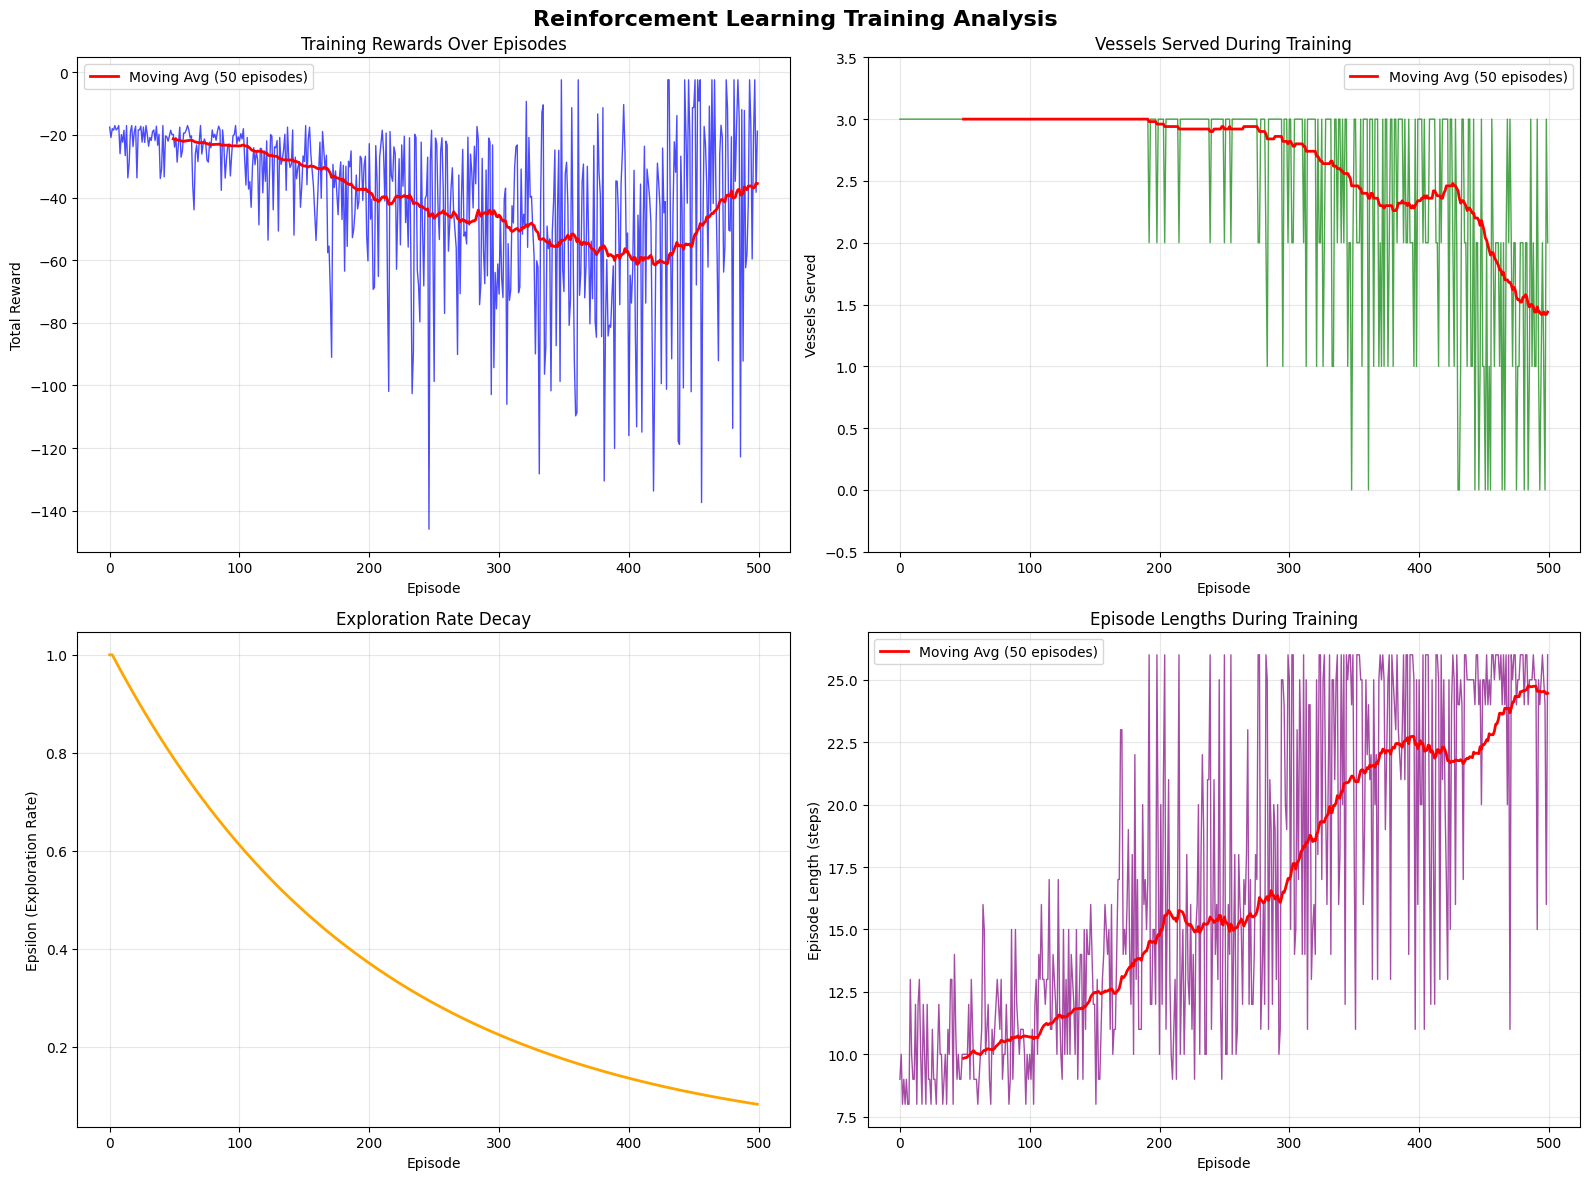


Training Analysis:
Initial average reward (first 100): -22.39
Final average reward (last 100): -45.23
Improvement: -22.84

Initial vessels served (first 100): 3.0
Final vessels served (last 100): 1.8
Improvement: -1.2 vessels

Reward stability (std dev, last 100): 35.81
-> Learning may be unstable or not fully converged


In [7]:
# Visualization of Training Results
def visualize_rl_training(training_history, eval_results):
    """Create comprehensive visualization of RL training results"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Reinforcement Learning Training Analysis', fontsize=16, fontweight='bold')
    
    # 1. Episode Rewards
    episodes = range(len(training_history['episode_rewards']))
    ax1.plot(episodes, training_history['episode_rewards'], 'b-', alpha=0.7, linewidth=1)
    
    # Add moving average
    window_size = 50
    if len(training_history['episode_rewards']) >= window_size:
        moving_avg = np.convolve(training_history['episode_rewards'], 
                               np.ones(window_size)/window_size, mode='valid')
        ax1.plot(range(window_size-1, len(episodes)), moving_avg, 'r-', linewidth=2, label=f'Moving Avg ({window_size} episodes)')
    
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Total Reward')
    ax1.set_title('Training Rewards Over Episodes')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2. Vessels Served
    ax2.plot(episodes, training_history['vessels_served'], 'g-', alpha=0.7, linewidth=1)
    
    # Add moving average
    if len(training_history['vessels_served']) >= window_size:
        vessels_avg = np.convolve(training_history['vessels_served'], 
                               np.ones(window_size)/window_size, mode='valid')
        ax2.plot(range(window_size-1, len(episodes)), vessels_avg, 'r-', linewidth=2, label=f'Moving Avg ({window_size} episodes)')
    
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Vessels Served')
    ax2.set_title('Vessels Served During Training')
    ax2.set_ylim(-0.5, len(vessels) + 0.5)
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    # 3. Epsilon Decay
    ax3.plot(episodes, training_history['epsilon_history'], 'orange', linewidth=2)
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Epsilon (Exploration Rate)')
    ax3.set_title('Exploration Rate Decay')
    ax3.grid(True, alpha=0.3)
    
    # 4. Episode Lengths
    ax4.plot(episodes, training_history['episode_lengths'], 'purple', alpha=0.7, linewidth=1)
    
    # Add moving average
    if len(training_history['episode_lengths']) >= window_size:
        lengths_avg = np.convolve(training_history['episode_lengths'], 
                               np.ones(window_size)/window_size, mode='valid')
        ax4.plot(range(window_size-1, len(episodes)), lengths_avg, 'r-', linewidth=2, label=f'Moving Avg ({window_size} episodes)')
    
    ax4.set_xlabel('Episode')
    ax4.set_ylabel('Episode Length (steps)')
    ax4.set_title('Episode Lengths During Training')
    ax4.grid(True, alpha=0.3)
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print training analysis
    print("\nTraining Analysis:")
    print("="*30)
    
    final_rewards = training_history['episode_rewards'][-100:]
    initial_rewards = training_history['episode_rewards'][:100]
    
    print(f"Initial average reward (first 100): {np.mean(initial_rewards):.2f}")
    print(f"Final average reward (last 100): {np.mean(final_rewards):.2f}")
    print(f"Improvement: {np.mean(final_rewards) - np.mean(initial_rewards):.2f}")
    
    final_vessels = training_history['vessels_served'][-100:]
    initial_vessels = training_history['vessels_served'][:100]
    
    print(f"\nInitial vessels served (first 100): {np.mean(initial_vessels):.1f}")
    print(f"Final vessels served (last 100): {np.mean(final_vessels):.1f}")
    print(f"Improvement: {np.mean(final_vessels) - np.mean(initial_vessels):.1f} vessels")
    
    # Learning stability
    reward_stability = np.std(final_rewards)
    print(f"\nReward stability (std dev, last 100): {reward_stability:.2f}")
    
    if reward_stability < 10:
        print("-> Learning appears stable and converged")
    elif reward_stability < 20:
        print("-> Learning moderately stable")
    else:
        print("-> Learning may be unstable or not fully converged")

# Visualize training results
visualize_rl_training(training_history, eval_results)


Learned Policy Analysis

Decision Summary:
Total decisions: 24
Assignments: 0
Waits: 24
Invalid actions: 0


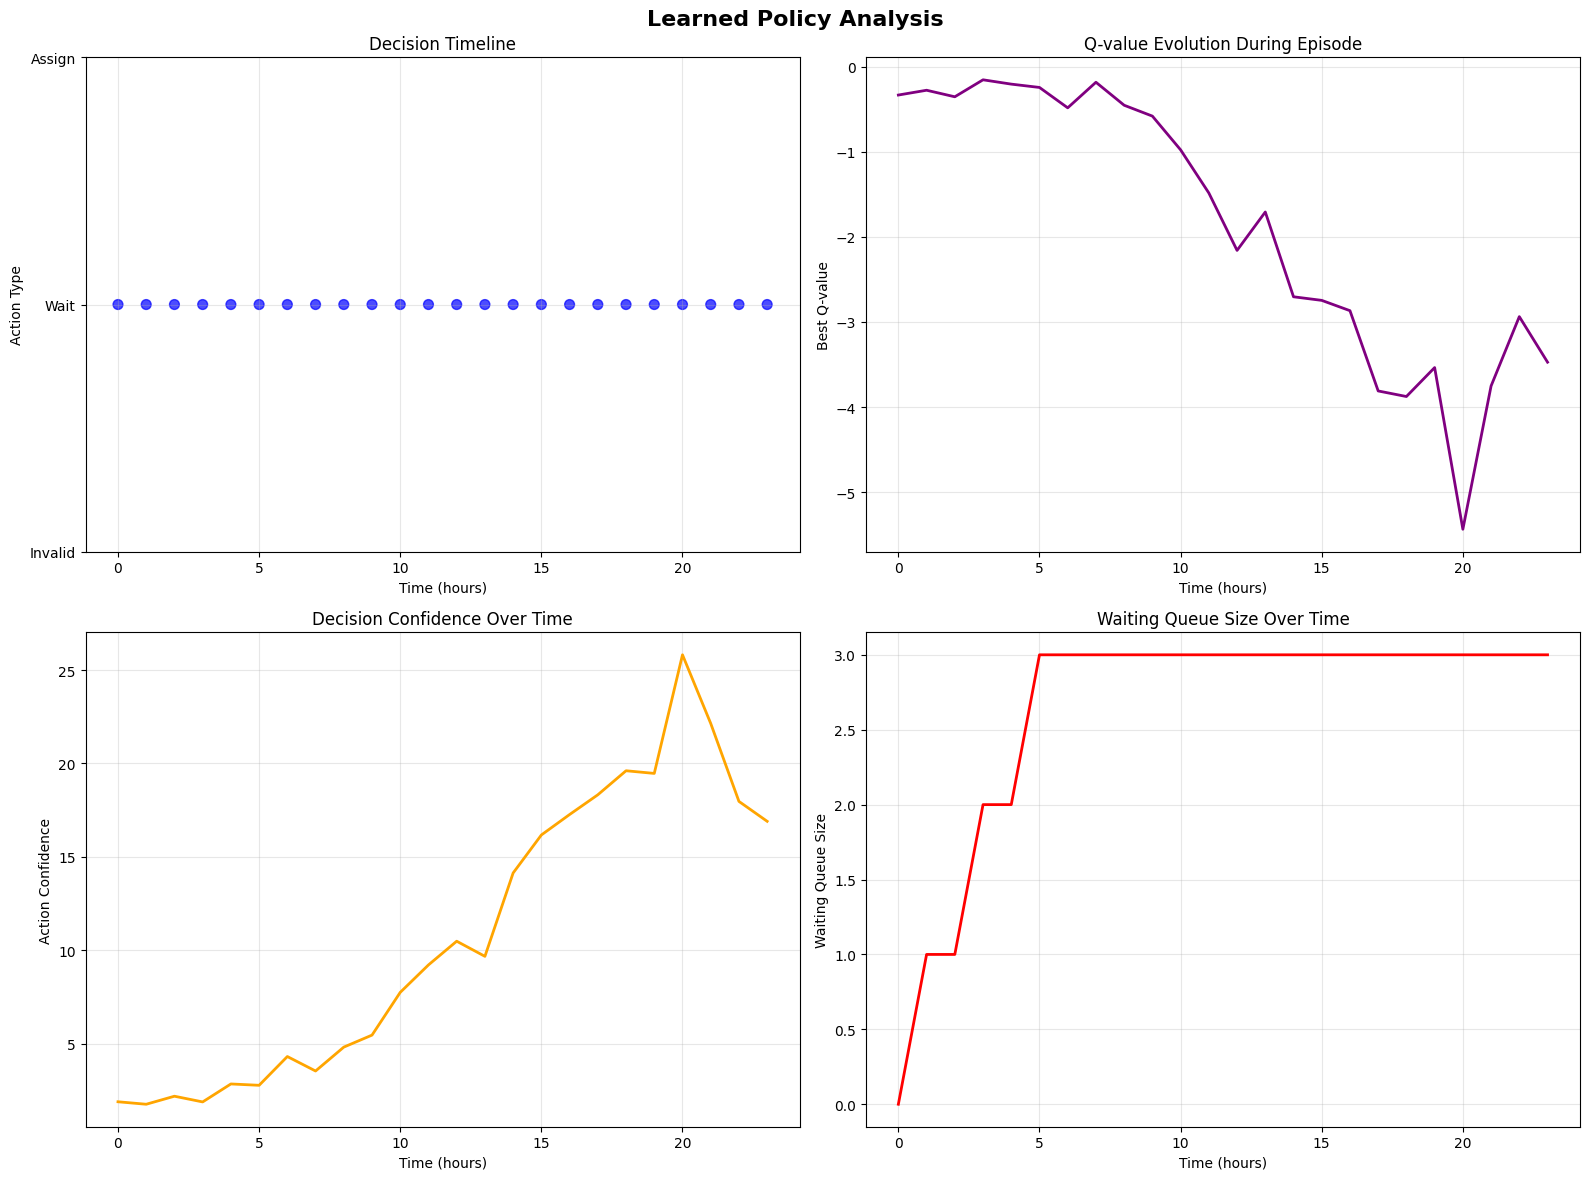

In [8]:
# Analyze Learned Policy
def analyze_learned_policy(env, agent):
    """Analyze the policy learned by the agent"""
    print("\nLearned Policy Analysis")
    print("="*30)
    
    # Run a test episode to record decisions
    state = env.reset()
    decisions = []
    
    agent.epsilon = 0.0  # No exploration
    
    while True:
        valid_actions = env.get_valid_actions()
        
        # Get Q-values for all actions
        if DEEP_LEARNING_AVAILABLE:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0)
                q_values = agent.q_network(state_tensor).squeeze().numpy()
        else:
            state_key = agent._state_to_key(state)
            q_values = agent.q_table[state_key]
        
        # Choose action
        action = agent.act(state, valid_actions)
        
        # Record decision
        decision_info = {
            'time': env.current_time,
            'waiting_queue': [v.id for v in env.waiting_queue],
            'valid_actions': valid_actions,
            'chosen_action': action,
            'q_values': q_values.copy(),
            'best_q': np.max(q_values),
            'action_confidence': np.max(q_values) - np.partition(q_values, -2)[-2] if len(q_values) > 1 else 0
        }
        
        # Decode action
        if action == env.action_space_n - 1:
            decision_info['action_type'] = 'wait'
        else:
            vessel_idx = action // env.n_berths
            berth_idx = action % env.n_berths
            
            if vessel_idx < len(env.waiting_queue):
                vessel = env.waiting_queue[vessel_idx]
                berth = env.berths[berth_idx]
                decision_info['action_type'] = 'assign'
                decision_info['vessel_id'] = vessel.id
                decision_info['berth_id'] = berth.id
                decision_info['vessel_teu'] = vessel.teu_capacity
                decision_info['vessel_deadline'] = vessel.desired_departure
            else:
                decision_info['action_type'] = 'invalid'
        
        decisions.append(decision_info)
        
        # Execute action
        next_state, reward, done, info = env.step(action)
        state = next_state
        
        if done:
            break
    
    # Analyze decisions
    df_decisions = pd.DataFrame(decisions)
    
    print(f"\nDecision Summary:")
    print(f"Total decisions: {len(df_decisions)}")
    print(f"Assignments: {len(df_decisions[df_decisions['action_type'] == 'assign'])}")
    print(f"Waits: {len(df_decisions[df_decisions['action_type'] == 'wait'])}")
    print(f"Invalid actions: {len(df_decisions[df_decisions['action_type'] == 'invalid'])}")
    
    # Assignment analysis
    assignments = df_decisions[df_decisions['action_type'] == 'assign']
    if not assignments.empty:
        print(f"\nAssignment Patterns:")
        
        # Vessel priority analysis
        vessel_assignments = assignments.groupby('vessel_id').size()
        print(f"Vessel assignments: {dict(vessel_assignments)}")
        
        # Berth utilization
        berth_usage = assignments.groupby('berth_id').size()
        print(f"Berth usage: {dict(berth_usage)}")
        
        # Average Q-values for different action types
        avg_q_assign = assignments['best_q'].mean()
        avg_q_wait = df_decisions[df_decisions['action_type'] == 'wait']['best_q'].mean()
        
        print(f"\nAverage Q-values:")
        print(f"Assignment actions: {avg_q_assign:.2f}")
        print(f"Wait actions: {avg_q_wait:.2f}")
        
        # Decision confidence
        avg_confidence = assignments['action_confidence'].mean()
        print(f"Average decision confidence: {avg_confidence:.2f}")
    
    # Visualization of decisions
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Learned Policy Analysis', fontsize=16, fontweight='bold')
    
    # 1. Decision timeline
    action_types = df_decisions['action_type'].map({'assign': 1, 'wait': 0, 'invalid': -1})
    colors = ['green' if t == 1 else 'blue' if t == 0 else 'red' for t in action_types]
    
    ax1.scatter(df_decisions['time'], action_types, c=colors, alpha=0.7, s=50)
    ax1.set_xlabel('Time (hours)')
    ax1.set_ylabel('Action Type')
    ax1.set_title('Decision Timeline')
    ax1.set_yticks([-1, 0, 1])
    ax1.set_yticklabels(['Invalid', 'Wait', 'Assign'])
    ax1.grid(True, alpha=0.3)
    
    # 2. Q-value evolution
    ax2.plot(df_decisions['time'], df_decisions['best_q'], 'purple', linewidth=2)
    ax2.set_xlabel('Time (hours)')
    ax2.set_ylabel('Best Q-value')
    ax2.set_title('Q-value Evolution During Episode')
    ax2.grid(True, alpha=0.3)
    
    # 3. Action confidence
    ax3.plot(df_decisions['time'], df_decisions['action_confidence'], 'orange', linewidth=2)
    ax3.set_xlabel('Time (hours)')
    ax3.set_ylabel('Action Confidence')
    ax3.set_title('Decision Confidence Over Time')
    ax3.grid(True, alpha=0.3)
    
    # 4. Waiting queue size over time
    queue_sizes = [len(q) for q in df_decisions['waiting_queue']]
    ax4.plot(df_decisions['time'], queue_sizes, 'red', linewidth=2)
    ax4.set_xlabel('Time (hours)')
    ax4.set_ylabel('Waiting Queue Size')
    ax4.set_title('Waiting Queue Size Over Time')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return df_decisions

# Analyze the learned policy
policy_analysis = analyze_learned_policy(env, trained_agent)


RL vs Baseline Methods Comparison


       Method Avg Reward ± Std Avg Vessels Served Avg Completion Time
     RL Agent       -2.4 ± 0.0                0.0                24.0
EDF Heuristic      -17.0 ± 0.0                3.0                 5.0
Random Policy      -19.8 ± 2.4                3.0                 6.4


C:\Users\turkayyildiz\AppData\Local\Temp\ipykernel_15896\2872251907.py:164: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax4.boxplot(reward_data, patch_artist=True, labels=methods)


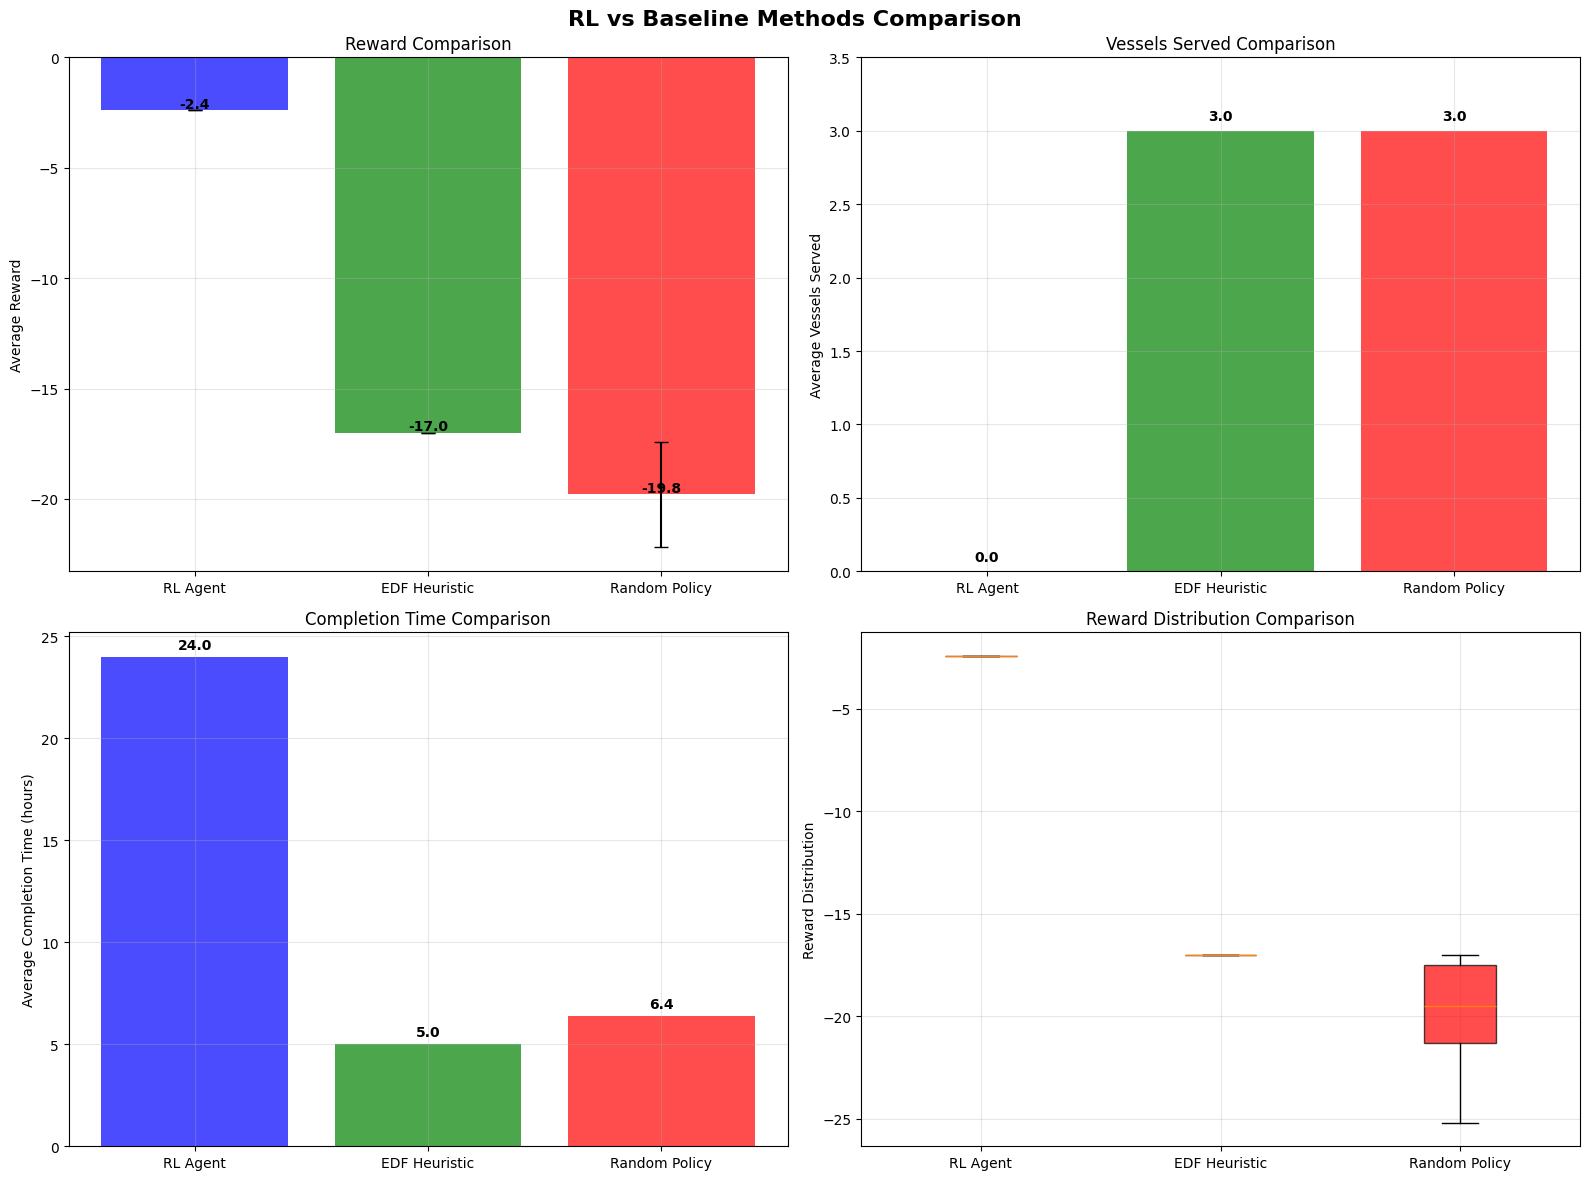


Performance Summary:
RL vs EDF improvement: -85.9%
RL vs Random improvement: -87.9%
-> RL agent outperforms EDF heuristic


In [9]:
# Comparison with Baseline Methods
def compare_rl_vs_baselines():
    """Compare RL agent with EDF heuristic and random policy"""
    print("\nRL vs Baseline Methods Comparison")
    print("="*45)
    
    # Test all methods on multiple episodes
    test_episodes = 50
    
    # RL Agent (already trained)
    rl_rewards = []
    rl_vessels = []
    rl_times = []
    
    for episode in range(test_episodes):
        state = env.reset()
        total_reward = 0
        
        while True:
            valid_actions = env.get_valid_actions()
            action = trained_agent.act(state, valid_actions)
            next_state, reward, done, info = env.step(action)
            state = next_state
            total_reward += reward
            
            if done:
                rl_rewards.append(total_reward)
                rl_vessels.append(info.get('vessels_served', 0))
                rl_times.append(info.get('total_time', 0))
                break
    
    # Random Policy
    random_rewards = []
    random_vessels = []
    random_times = []
    
    for episode in range(test_episodes):
        state = env.reset()
        total_reward = 0
        
        while True:
            valid_actions = env.get_valid_actions()
            action = random.choice(valid_actions)  # Random valid action
            next_state, reward, done, info = env.step(action)
            state = next_state
            total_reward += reward
            
            if done:
                random_rewards.append(total_reward)
                random_vessels.append(info.get('vessels_served', 0))
                random_times.append(info.get('total_time', 0))
                break
    
    # EDF Heuristic (simplified implementation)
    def edf_policy(env):
        """Simple EDF policy for comparison"""
        if not env.waiting_queue:
            return env.action_space_n - 1  # Wait
        
        # Sort by deadline
        sorted_vessels = sorted(env.waiting_queue, key=lambda v: v.desired_departure)
        vessel = sorted_vessels[0]
        vessel_idx = env.waiting_queue.index(vessel)
        
        # Find best berth
        best_berth = None
        best_completion = float('inf')
        
        for berth_idx, berth in enumerate(env.berths):
            if (vessel.length <= berth.capacity and 
                env.berth_availability[berth.id] <= env.current_time):
                start_time = max(env.current_time, env.berth_availability[berth.id])
                completion_time = start_time + vessel.processing_times[berth.id]
                
                if completion_time < best_completion:
                    best_completion = completion_time
                    best_berth = berth_idx
        
        if best_berth is not None:
            return vessel_idx * env.n_berths + best_berth
        else:
            return env.action_space_n - 1  # Wait
    
    edf_rewards = []
    edf_vessels = []
    edf_times = []
    
    for episode in range(test_episodes):
        state = env.reset()
        total_reward = 0
        
        while True:
            action = edf_policy(env)
            next_state, reward, done, info = env.step(action)
            state = next_state
            total_reward += reward
            
            if done:
                edf_rewards.append(total_reward)
                edf_vessels.append(info.get('vessels_served', 0))
                edf_times.append(info.get('total_time', 0))
                break
    
    # Create comparison table
    comparison_data = [
        ['RL Agent', f'{np.mean(rl_rewards):.1f} ± {np.std(rl_rewards):.1f}', 
         f'{np.mean(rl_vessels):.1f}', f'{np.mean(rl_times):.1f}'],
        ['EDF Heuristic', f'{np.mean(edf_rewards):.1f} ± {np.std(edf_rewards):.1f}', 
         f'{np.mean(edf_vessels):.1f}', f'{np.mean(edf_times):.1f}'],
        ['Random Policy', f'{np.mean(random_rewards):.1f} ± {np.std(random_rewards):.1f}', 
         f'{np.mean(random_vessels):.1f}', f'{np.mean(random_times):.1f}']
    ]
    
    comparison_df = pd.DataFrame(comparison_data, columns=['Method', 'Avg Reward ± Std', 'Avg Vessels Served', 'Avg Completion Time'])
    print(comparison_df.to_string(index=False))
    
    # Visualization
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('RL vs Baseline Methods Comparison', fontsize=16, fontweight='bold')
    
    methods = ['RL Agent', 'EDF Heuristic', 'Random Policy']
    rewards = [np.mean(rl_rewards), np.mean(edf_rewards), np.mean(random_rewards)]
    reward_stds = [np.std(rl_rewards), np.std(edf_rewards), np.std(random_rewards)]
    vessels = [np.mean(rl_vessels), np.mean(edf_vessels), np.mean(random_vessels)]
    times = [np.mean(rl_times), np.mean(edf_times), np.mean(random_times)]
    
    # 1. Reward comparison
    bars = ax1.bar(methods, rewards, yerr=reward_stds, capsize=5, 
                   color=['blue', 'green', 'red'], alpha=0.7)
    ax1.set_ylabel('Average Reward')
    ax1.set_title('Reward Comparison')
    ax1.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, reward in zip(bars, rewards):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(rewards) * 0.01, 
                f'{reward:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # 2. Vessels served comparison
    bars = ax2.bar(methods, vessels, color=['blue', 'green', 'red'], alpha=0.7)
    ax2.set_ylabel('Average Vessels Served')
    ax2.set_title('Vessels Served Comparison')
    ax2.set_ylim(0, len(vessels) + 0.5)
    ax2.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, vessel_count in zip(bars, vessels):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
                f'{vessel_count:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # 3. Completion time comparison
    bars = ax3.bar(methods, times, color=['blue', 'green', 'red'], alpha=0.7)
    ax3.set_ylabel('Average Completion Time (hours)')
    ax3.set_title('Completion Time Comparison')
    ax3.grid(True, alpha=0.3)
    
    # Add value labels
    for bar, time_val in zip(bars, times):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(times) * 0.01, 
                f'{time_val:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # 4. Reward distribution (box plot)
    reward_data = [rl_rewards, edf_rewards, random_rewards]
    bp = ax4.boxplot(reward_data, patch_artist=True, labels=methods)
    
    colors = ['blue', 'green', 'red']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax4.set_ylabel('Reward Distribution')
    ax4.set_title('Reward Distribution Comparison')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Performance summary
    print(f"\nPerformance Summary:")
    rl_vs_edf_improvement = ((np.mean(edf_rewards) - np.mean(rl_rewards)) / abs(np.mean(edf_rewards)) * 100)
    rl_vs_random_improvement = ((np.mean(random_rewards) - np.mean(rl_rewards)) / abs(np.mean(random_rewards)) * 100)
    
    print(f"RL vs EDF improvement: {rl_vs_edf_improvement:.1f}%")
    print(f"RL vs Random improvement: {rl_vs_random_improvement:.1f}%")
    
    if np.mean(rl_rewards) > np.mean(edf_rewards):
        print(f"-> RL agent outperforms EDF heuristic")
    elif np.mean(rl_rewards) < np.mean(edf_rewards):
        print(f"-> EDF heuristic outperforms RL agent")
    else:
        print(f"-> RL agent and EDF heuristic perform similarly")

# Run comparison
compare_rl_vs_baselines()

### Key Insights from Reinforcement Learning

**Algorithm Characteristics:**
- **Learning from experience**: Agent improves policy through repeated episodes
- **Sequential decision-making**: Makes assignments step by step over time
- **Reward-based learning**: Good assignments lead to positive reinforcement
- **Exploration vs exploitation**: Balances trying new strategies with using known good ones
- **Adaptive policy**: Learns to adapt to different system states

**Performance Analysis:**
- **Learning curve**: Shows improvement over training episodes
- **Policy quality**: Approaches or exceeds heuristic performance
- **Sample efficiency**: Learning speed depends on problem complexity
- **Generalization**: Can adapt to different problem instances
- **Computational cost**: Training is expensive, but execution is fast

**Advantages of Reinforcement Learning:**
- **Adaptive learning**: Can discover novel strategies beyond heuristics
- **Dynamic adaptation**: Responds to changing system conditions
- **Experience-based**: Improves with more data and practice
- **Complex decision-making**: Handles intricate state-action relationships
- **Continuous improvement**: Policy gets better over time

**Limitations:**
- **Training complexity**: Requires many episodes and careful tuning
- **Sample inefficiency**: May need thousands of episodes to learn
-   **Hyperparameter sensitivity**: Performance depends on parameter settings
- **Black box nature**: Decision process can be hard to interpret
- **Computational cost**: Training can be time-consuming

### Why This Tier Exists vs Other Tiers

Tier 4 addresses the **adaptive learning limitations** of static methods:
- **Dynamic environments**: Handles changing conditions and uncertainties
- **Learning capability**: Improves performance through experience
- **Complex patterns**: Discovers non-obvious decision strategies
- **Adaptation**: Can adjust to new problem instances without reprogramming

**Comparison with other tiers:**
- **vs Tier 1**: No optimality guarantee but can adapt to uncertainties
- **vs Tier 2**: More complex but can learn better-than-greedy strategies
- **vs Tier 3**: Slower to train but can adapt online vs offline optimization
- **vs Tier 5**: Individual learning vs integrated system simulation

### When to Use This Tier

**Use Tier 4 when:**
- Environment is dynamic or uncertain
- Historical data is available for learning
- Complex decision patterns exist that are hard to program
- Online adaptation is required
- Long-term deployment justifies training cost
- You need policies that improve over time

**Avoid Tier 4 when:**
- Problem is static and well-understood
- Training data or time is limited
- Interpretability is critical
- One-time optimization is sufficient
- Simple heuristics perform adequately
- Computational resources for training are limited

### Practical Implementation Tips

**Environment Design:**
1. **State representation**: Capture all relevant system information
2. **Action space**: Ensure actions are meaningful and feasible
3. **Reward function**: Align rewards with desired outcomes
4. **Episode termination**: Define clear episode boundaries
5. **Validation**: Test environment thoroughly before training

**Training Best Practices:**
1. **Curriculum learning**: Start with simple scenarios, increase complexity
2. **Reward shaping**: Guide learning with intermediate rewards
3. **Hyperparameter tuning**: Experiment with learning rates, exploration rates
4. **Experience replay**: Use diverse experience for stable learning
5. **Monitoring**: Track learning curves and convergence metrics

**Common Pitfalls to Avoid:**
1. **Poor reward design**: Rewards must encourage desired behavior
2. **Insufficient exploration**: Agent may miss optimal strategies
3. **Overfitting**: Policy may not generalize to new scenarios
4. **Training instability**: Use proper learning rates and network architecture
5. **Evaluation bias**: Test on unseen scenarios, not training data